In [3]:
import pandas as pd

btc = pd.read_parquet("btc_daily.parquet")

btc.head()

,Open,High,Low,Close,Volume
datetime,,,,,
2012-01-01,4.58,4.84,4.58,4.84,10.000000
2012-01-02,4.84,5.00,4.84,5.00,10.100000
2012-01-03,5.00,5.32,5.00,5.29,107.085281
2012-01-04,5.29,5.57,4.93,5.57,107.233260
2012-01-05,5.57,6.46,5.57,6.42,70.328742


Text(0.5, 1.0, 'Bitcoin Return Distribution')

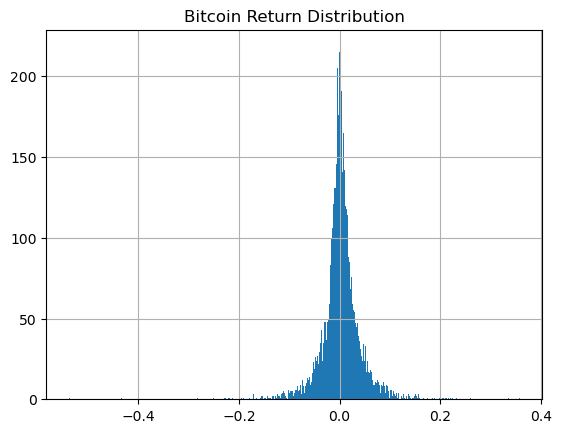

In [7]:
import matplotlib.pyplot as plt

btc["return"] = btc["Close"].pct_change()

btc["return"].hist(bins=500)
plt.title("Bitcoin Return Distribution")

In [9]:
# Skewness & Kurtosis

btc["return"].skew()
btc["return"].kurtosis()

15.849612703010378

<Axes: xlabel='datetime'>

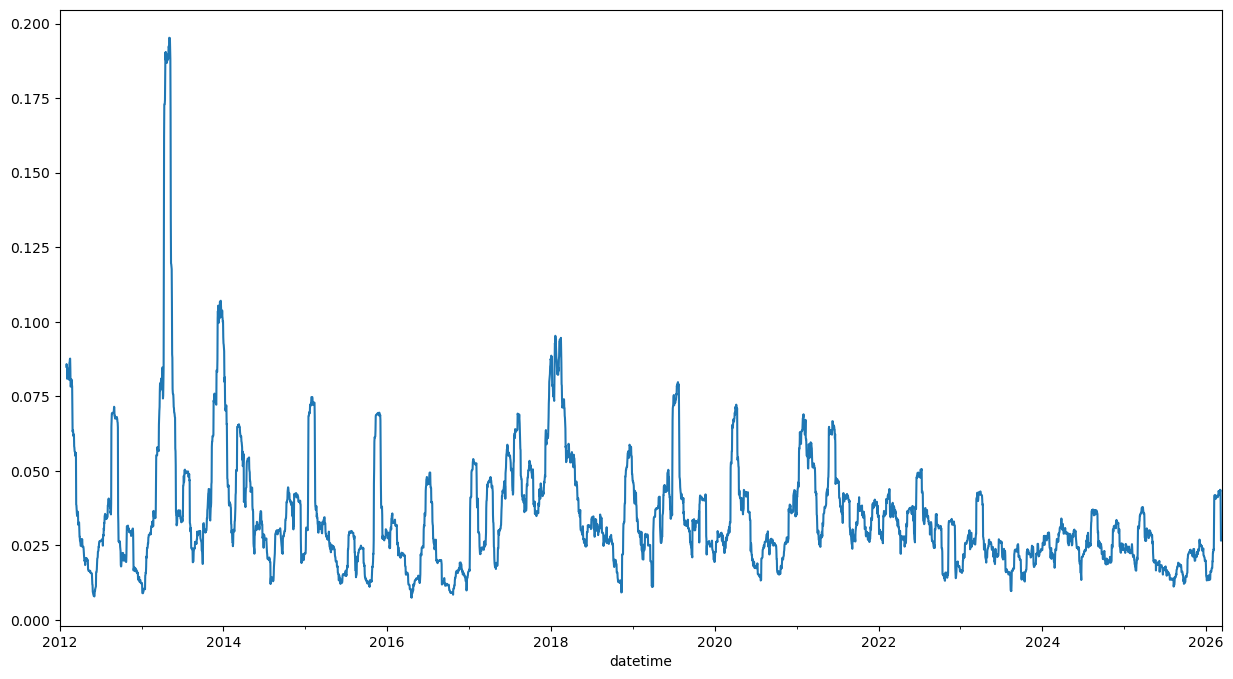

In [15]:
# Volatility Clustering

btc["rolling_vol"] = btc["return"].rolling(30).std()

btc["rolling_vol"].plot(figsize=(15,8))

<Axes: xlabel='datetime'>

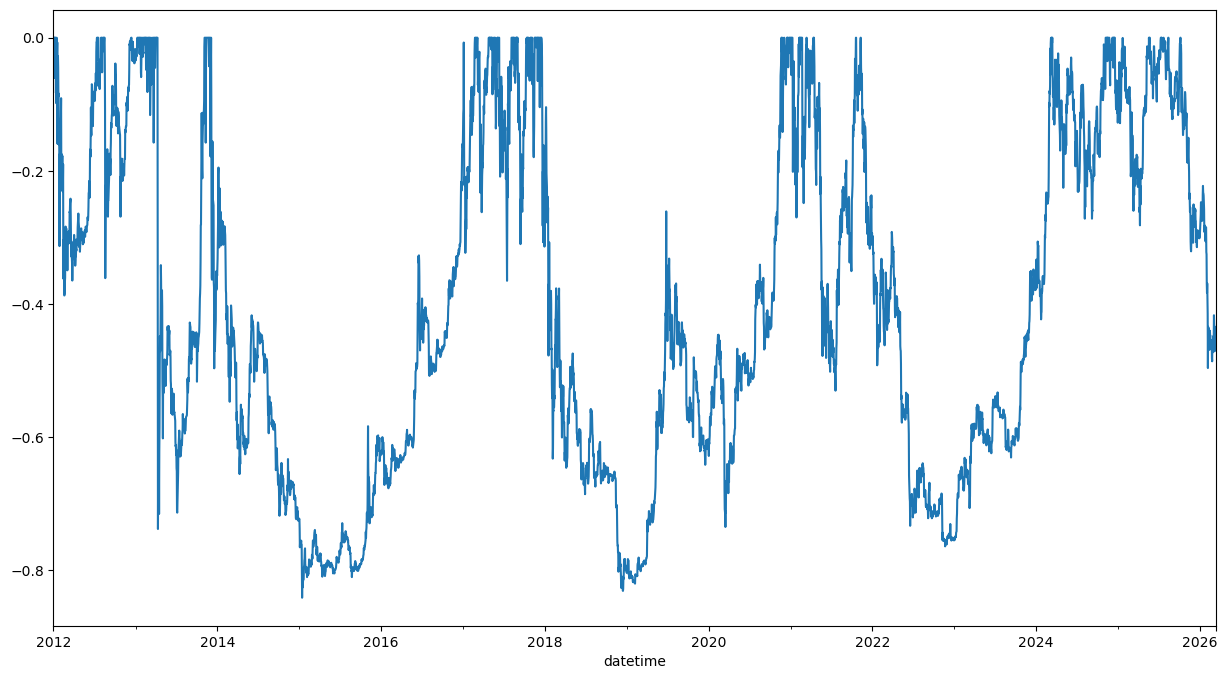

In [19]:
# Drawdown Analysis

cum = (1 + btc["return"]).cumprod()

rolling_max = cum.cummax()

drawdown = cum / rolling_max - 1

drawdown.plot(figsize=(15,8))